# PHQ-8 Depression Detection — BERT + Attention Pooling + MLP (Classification)

**Architecture**: Frozen BERT (`bert-base-uncased`) → sequence of 768-dim [CLS] chunk embeddings → **Learned Attention Pooling** → 768-dim participant vector → `MLP(768→256→1)` → binary logit.

**Task**: Binary classification — depressed (PHQ-8 ≥ 10) vs. control (PHQ-8 < 10).

**Why BERT for text**:
- Transcripts capture linguistic and semantic cues (word choice, coherence, topic shifts) that are strong indicators of depression.
- BERT's bidirectional self-attention captures context-dependent word meaning and sentence-level semantics.
- The [CLS] token embedding is a rich summary of each text chunk.

**Input**: Transcripts from `dataset/transcripts/{pid}_P.txt` chunked into 200-token windows with 50-token overlap.

**Features**: Each chunk → BERT [CLS] embedding (768-dim). Cached to `processed/bert_features_cls.npz` on first run.

**Target**: Binary label — 0 (control) or 1 (depressed).

## 1. Install Dependencies

In [35]:
!pip install transformers tqdm pandas numpy scikit-learn matplotlib --quiet
print("All packages ready.")

All packages ready.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Imports & Configuration

In [36]:
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
from torch.optim import Adam

import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, classification_report
)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tqdm import tqdm

print("Imports successful.")

Imports successful.


In [37]:
# --- Paths ---
BASE_DIR        = Path("..")
DATASET_DIR     = BASE_DIR / "dataset"
TRANSCRIPT_DIR  = DATASET_DIR / "cleaned"
PROCESSED_DIR   = BASE_DIR / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_CSV = DATASET_DIR / "train_split_Depression_AVEC2017.csv"
DEV_CSV   = DATASET_DIR / "dev_split_Depression_AVEC2017.csv"
TEST_CSV  = DATASET_DIR / "full_test_split.csv"

FEATURE_CACHE = PROCESSED_DIR / "bert_features_cls.npz"

BERT_MODEL_ID = str(Path("models") / "bert")   # local model folder inside experiments/

SAVE_DIR = BASE_DIR / "experiments" / "best_model" / "bert_cls"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# --- Device ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device   : {DEVICE}")
print(f"Feature cache  : {FEATURE_CACHE.resolve()}")
print(f"Checkpoint dir : {SAVE_DIR.resolve()}")

Using device   : cuda
Feature cache  : C:\Users\edgar\OneDrive\Documents\Term_8\Deep_learning\Project\phq8_depression_detection\processed\bert_features_cls.npz
Checkpoint dir : C:\Users\edgar\OneDrive\Documents\Term_8\Deep_learning\Project\phq8_depression_detection\experiments\best_model\bert_cls


## 3. Load Label Files

Binary labels:
- `PHQ8_Binary` in train/dev CSVs — 1 if PHQ-8 ≥ 10, else 0
- `PHQ_Binary` in test CSV (same threshold, different column name)

In [38]:
train_df = pd.read_csv(TRAIN_CSV)[["Participant_ID", "PHQ8_Binary"]]
dev_df   = pd.read_csv(DEV_CSV)[["Participant_ID", "PHQ8_Binary"]]
test_df  = pd.read_csv(TEST_CSV)[["Participant_ID", "PHQ_Binary"]].rename(
    columns={"PHQ_Binary": "PHQ8_Binary"}
)

train_labels = dict(zip(train_df.Participant_ID, train_df.PHQ8_Binary))
dev_labels   = dict(zip(dev_df.Participant_ID,   dev_df.PHQ8_Binary))
test_labels  = dict(zip(test_df.Participant_ID,  test_df.PHQ8_Binary))

pid_to_label = {**train_labels, **dev_labels, **test_labels}
pid_to_split = (
    {pid: "train" for pid in train_labels}
    | {pid: "dev"   for pid in dev_labels}
    | {pid: "test"  for pid in test_labels}
)

for name, labels in [("Train", train_labels), ("Dev", dev_labels), ("Test", test_labels)]:
    dep  = sum(labels.values())
    ctrl = len(labels) - dep
    print(f"{name:5s}: {len(labels):3d} participants  "
          f"depressed: {dep}  control: {ctrl}")

Train: 107 participants  depressed: 30  control: 77
Dev  :  35 participants  depressed: 12  control: 23
Test :  47 participants  depressed: 14  control: 33


## 4. Feature Extraction

Transcripts in `dataset/transcripts/` are chunked into **200-token windows** with a **50-token overlap**.
Each chunk is passed through frozen BERT and the **[CLS] token embedding** is taken → **768-dim feature vector**.

Features are saved to `processed/bert_features_cls.npz` and reloaded on subsequent runs.

In [39]:
CHUNK_TOKENS  = 200   # tokens per chunk (excluding [CLS]/[SEP])
OVERLAP_TOKENS = 50  # overlapping tokens between consecutive chunks
STRIDE        = CHUNK_TOKENS - OVERLAP_TOKENS

if FEATURE_CACHE.exists():
    print(f"Feature cache found at {FEATURE_CACHE.name} — skipping extraction.")
else:
    print(f"Extracting BERT features → {FEATURE_CACHE.name}")
    print(f"  Model      : {BERT_MODEL_ID}")
    print(f"  Chunk size : {CHUNK_TOKENS} tokens   Overlap : {OVERLAP_TOKENS} tokens")

    from transformers import BertModel, BertTokenizerFast

    tokenizer = BertTokenizerFast.from_pretrained(BERT_MODEL_ID)
    bert      = BertModel.from_pretrained(BERT_MODEL_ID)
    bert.eval().to(DEVICE)
    for param in bert.parameters():
        param.requires_grad = False
    print("BERT loaded and frozen.")

    all_feats, all_bin_labels, all_pids, all_splits = [], [], [], []

    transcript_files = sorted(TRANSCRIPT_DIR.glob("*_P.txt"))
    print(f"\nProcessing {len(transcript_files)} transcript files ...")

    for txt_path in tqdm(transcript_files):
        pid = int(txt_path.stem.split("_")[0])
        if pid not in pid_to_label:
            continue

        split = pid_to_split[pid]
        label = pid_to_label[pid]

        text = txt_path.read_text(encoding="utf-8").strip()
        if not text:
            continue

        # Tokenize full transcript (no special tokens yet)
        token_ids = tokenizer.encode(text, add_special_tokens=False)

        # Sliding-window chunking over token IDs
        starts = list(range(0, max(1, len(token_ids) - CHUNK_TOKENS + 1), STRIDE))
        if not starts:
            starts = [0]

        for start in starts:
            chunk_ids = token_ids[start : start + CHUNK_TOKENS]

            # Add [CLS] and [SEP]
            input_ids      = [tokenizer.cls_token_id] + chunk_ids + [tokenizer.sep_token_id]
            attention_mask = [1] * len(input_ids)

            input_ids_t  = torch.tensor([input_ids],      device=DEVICE)
            attn_mask_t  = torch.tensor([attention_mask], device=DEVICE)

            with torch.no_grad():
                outputs = bert(
                    input_ids=input_ids_t,
                    attention_mask=attn_mask_t,
                )
            # [CLS] embedding from last hidden state
            feat = outputs.last_hidden_state[0, 0].cpu().numpy()  # (768,)

            all_feats.append(feat)
            all_bin_labels.append(label)
            all_pids.append(pid)
            all_splits.append(split.encode())

    np.savez_compressed(
        FEATURE_CACHE,
        feats         = np.array(all_feats,      dtype=np.float32),
        binary_labels = np.array(all_bin_labels, dtype=np.int32),
        pids          = np.array(all_pids,        dtype=np.int32),
        splits        = np.array(all_splits),
    )
    print(f"\nSaved {len(all_feats):,} chunk features → {FEATURE_CACHE}")

    del bert, tokenizer
    torch.cuda.empty_cache()

Feature cache found at bert_features_cls.npz — skipping extraction.


## 5. Build Participant-Level Dataset

Load the cached features and group chunks by participant.
The attention layer will learn to weight chunks — no ordering assumption needed.

In [40]:
print(f"Loading features from {FEATURE_CACHE.name} ...")
cache           = np.load(FEATURE_CACHE, allow_pickle=False)
all_feats_np    = cache["feats"]          # (N, 768)
all_labels_np   = cache["binary_labels"]  # (N,)
all_pids_np     = cache["pids"]           # (N,)
all_splits_np   = cache["splits"]         # (N,)  byte strings

in_memory = {
    "train": defaultdict(lambda: {"feats": [], "label": None}),
    "dev":   defaultdict(lambda: {"feats": [], "label": None}),
    "test":  defaultdict(lambda: {"feats": [], "label": None}),
}

for feat, lbl, pid, split_b in zip(
    all_feats_np, all_labels_np, all_pids_np, all_splits_np
):
    split = split_b.decode()
    pid   = int(pid)
    in_memory[split][pid]["feats"].append(feat)
    in_memory[split][pid]["label"] = int(lbl)

splits_list = {s: list(in_memory[s].items()) for s in ("train", "dev", "test")}

print(f"\n{'Split':10s}  {'Participants':>12}  {'Chunks':>8}  {'Depressed':>9}  {'Control':>7}")
print("-" * 52)
for s, name in [("train", "train"), ("dev", "validation"), ("test", "test")]:
    n_chunks = sum(len(d["feats"]) for _, d in splits_list[s])
    n_dep    = sum(d["label"] for _, d in splits_list[s])
    n_ctrl   = len(splits_list[s]) - n_dep
    print(f"{name:10s}  {len(splits_list[s]):12d}  {n_chunks:8,}  {n_dep:9d}  {n_ctrl:7d}")

Loading features from bert_features_cls.npz ...

Split       Participants    Chunks  Depressed  Control
----------------------------------------------------
train                107     1,032         30       77
validation            35       370         12       23
test                  47       541         14       33


## 6. Training Configuration

In [41]:
# --- Model hyper-parameters ---
BERT_DIM   = 768
MLP_HIDDEN = 64
DROPOUT    = 0.5

# --- Training hyper-parameters ---
PARTICIPANT_BATCH_SIZE  = 16
NUM_EPOCHS              = 500
LEARNING_RATE           = 5e-5
WEIGHT_DECAY            = 1e-4
EARLY_STOPPING_PATIENCE = 50
CHECKPOINT_FREQ         = 50
GRAD_CLIP_NORM          = 1.0

print("Training configuration:")
print(f"  BERT feature dim       : {BERT_DIM}")
print(f"  MLP hidden dim         : {MLP_HIDDEN}")
print(f"  Dropout                : {DROPOUT}")
print(f"  Participant batch size : {PARTICIPANT_BATCH_SIZE}")
print(f"  Epochs                 : {NUM_EPOCHS}")
print(f"  Learning rate          : {LEARNING_RATE}")
print(f"  Weight decay           : {WEIGHT_DECAY}")
print(f"  Early stopping         : {EARLY_STOPPING_PATIENCE} epochs patience")
print(f"  Grad clip norm         : {GRAD_CLIP_NORM}")

Training configuration:
  BERT feature dim       : 768
  MLP hidden dim         : 64
  Dropout                : 0.5
  Participant batch size : 16
  Epochs                 : 500
  Learning rate          : 5e-05
  Weight decay           : 0.0001
  Early stopping         : 50 epochs patience
  Grad clip norm         : 1.0


## 7. Model — BERT Attention Pooling + MLP Classifier

```
Input  : (T, 768)   — [CLS] chunk embeddings for one participant
         ↓ Linear(768, 1) + softmax over T
         ↓ attention-weighted sum → (768,)   [learned chunk importance]
         ↓ LayerNorm(768)
         ↓ Linear(768, 256) + ReLU
         ↓ Dropout(0.3)
         ↓ Linear(256, 1)
Output : scalar logit  (sigmoid → probability of depression)
```

In [42]:
class BERTAttentionMLPClassifier(nn.Module):
    """
    Attention pooling + LayerNorm + MLP binary classifier on top of frozen BERT [CLS] features.

    Input  : (T, 768)  — chunk [CLS] embeddings for one participant
    Output : scalar logit  — positive = depressed, negative = control
    """
    def __init__(
        self,
        input_dim:  int   = BERT_DIM,
        hidden_dim: int   = MLP_HIDDEN,
        dropout:    float = DROPOUT,
    ):
        super().__init__()
        # Learns a scalar importance score per chunk
        self.attention  = nn.Linear(input_dim, 1)
        # Normalise the pooled vector before classification
        self.norm       = nn.LayerNorm(input_dim)
        # MLP classification head
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x : (T, 768)
        attn_weights = torch.softmax(self.attention(x), dim=0)  # (T, 1)
        pooled       = (attn_weights * x).sum(dim=0)            # (768,)
        pooled       = self.norm(pooled)                        # (768,)  normalised
        return self.classifier(pooled).squeeze()                # scalar logit


model = BERTAttentionMLPClassifier().to(DEVICE)

# Sanity-check forward pass
with torch.no_grad():
    dummy = torch.zeros(10, BERT_DIM, device=DEVICE)
    out   = model(dummy)
    print(f"Output shape (10 chunks): {out.shape}  (expected: torch.Size([]))")

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")

Output shape (10 chunks): torch.Size([])  (expected: torch.Size([]))
Trainable parameters: 51,586


## 8. Training Loop

**Participant-level training**: each participant's chunks are fed as a set → attention pooling → one logit → `BCEWithLogitsLoss`.

**Class-weighted loss**: `pos_weight = n_control / n_depressed` compensates for class imbalance.

**Threshold tuning**: after training, the decision threshold is tuned on the validation set to maximise macro F1.

In [43]:
# ── Class-weighted loss ───────────────────────────────────────────────────────
n_dep_train  = sum(d["label"] for _, d in splits_list["train"])
n_ctrl_train = len(splits_list["train"]) - n_dep_train
pos_weight   = torch.tensor(n_ctrl_train / n_dep_train, dtype=torch.float32, device=DEVICE)
print(f"Training class counts — depressed: {n_dep_train}, control: {n_ctrl_train}")
print(f"BCEWithLogitsLoss pos_weight: {pos_weight.item():.4f}")

criterion          = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer          = Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

history = {
    "train_loss": [], "train_acc": [],
    "val_loss":   [], "val_acc":   [],
}
best_val_loss      = float("inf")
epochs_no_improve  = 0
train_participants = splits_list["train"]


def train_epoch():
    model.train()
    idx     = torch.randperm(len(train_participants)).tolist()
    batches = [
        idx[i : i + PARTICIPANT_BATCH_SIZE]
        for i in range(0, len(idx), PARTICIPANT_BATCH_SIZE)
    ]
    total_loss = 0.0
    correct    = 0
    n          = len(train_participants)

    for batch in batches:
        optimizer.zero_grad()
        batch_size = len(batch)

        for i in batch:
            _, data = train_participants[i]
            feats = torch.tensor(
                np.array(data["feats"]), dtype=torch.float32, device=DEVICE
            )
            label = torch.tensor(
                float(data["label"]), dtype=torch.float32, device=DEVICE
            )

            logit = model(feats)
            loss  = criterion(logit, label) / batch_size
            loss.backward()

            total_loss += loss.item() * batch_size
            pred        = 1 if torch.sigmoid(logit).item() >= 0.5 else 0
            correct    += int(pred == data["label"])

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
        optimizer.step()

    return total_loss / n, correct / n


def evaluate(split: str, threshold: float = 0.5):
    """
    Participant-level evaluation.
    Returns (avg_loss, accuracy, results_df).
    """
    model.eval()
    total_loss = 0.0
    correct    = 0
    records    = []

    with torch.no_grad():
        for pid, data in splits_list[split]:
            feats = torch.tensor(
                np.array(data["feats"]), dtype=torch.float32, device=DEVICE
            )
            label = torch.tensor(
                float(data["label"]), dtype=torch.float32, device=DEVICE
            )

            logit      = model(feats)
            loss       = criterion(logit, label)
            total_loss += loss.item()

            pred_prob = torch.sigmoid(logit).item()
            pred      = 1 if pred_prob >= threshold else 0
            correct  += int(pred == data["label"])
            records.append((pid, pred, pred_prob, data["label"]))

    n   = len(splits_list[split])
    df  = pd.DataFrame(records, columns=["participant_id", "pred", "pred_prob", "label"])
    return total_loss / n, correct / n, df


# ── Training ──────────────────────────────────────────────────────────────────
print(f"\nTraining on {len(train_participants)} participants for up to {NUM_EPOCHS} epochs.")
print()
print(f"{'Epoch':>6}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>8}  {'Val Acc':>7}")
print("-" * 52)

for epoch in range(1, NUM_EPOCHS + 1):

    train_loss, train_acc    = train_epoch()
    val_loss,   val_acc, _   = evaluate("dev")

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"{epoch:6d}  {train_loss:10.4f}  {train_acc:9.4f}  {val_loss:8.4f}  {val_acc:7.4f}")

    if epoch % CHECKPOINT_FREQ == 0:
        ckpt_path = SAVE_DIR / f"epoch{epoch}_bert_cls.pth"
        torch.save({
            "epoch":                epoch,
            "model_state_dict":     model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_loss":           train_loss,
            "val_loss":             val_loss,
        }, ckpt_path)

    if val_loss < best_val_loss:
        best_val_loss     = val_loss
        epochs_no_improve = 0
        best_path = SAVE_DIR / "bert_cls_best.pth"
        torch.save({
            "epoch":                epoch,
            "model_state_dict":     model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_loss":             val_loss,
            "val_acc":              val_acc,
        }, best_path)
        print(f"  *** Best model saved  "
              f"val loss {val_loss:.4f}  val acc {val_acc:.4f} ***")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
            print(f"\nEarly stopping at epoch {epoch} — "
                  f"no improvement for {EARLY_STOPPING_PATIENCE} epochs.")
            break

print("\nTraining complete.")
best_epoch_idx = history["val_loss"].index(min(history["val_loss"]))
print(f"Best val loss     : {min(history['val_loss']):.4f}  (epoch {best_epoch_idx + 1})")
print(f"Best val accuracy : {history['val_acc'][best_epoch_idx]:.4f}")

# ── Threshold tuning on validation set ───────────────────────────────────────
best_ckpt = torch.load(
    SAVE_DIR / "bert_cls_best.pth",
    map_location=DEVICE,
    weights_only=True,
)
model.load_state_dict(best_ckpt["model_state_dict"])

_, _, val_df = evaluate("dev", threshold=0.5)
best_thresh, best_val_f1 = 0.5, 0.0
for thresh in np.arange(0.1, 0.91, 0.05):
    y_t = val_df["label"].values.astype(int)
    y_p = (val_df["pred_prob"].values >= thresh).astype(int)
    f1  = f1_score(y_t, y_p, average="macro", zero_division=0)
    if f1 > best_val_f1:
        best_val_f1  = f1
        best_thresh  = float(thresh)

print(f"\nThreshold tuned on validation set → {best_thresh:.2f}  (val macro-F1 = {best_val_f1:.4f})")

Training class counts — depressed: 30, control: 77
BCEWithLogitsLoss pos_weight: 2.5667

Training on 107 participants for up to 500 epochs.

 Epoch  Train Loss  Train Acc  Val Loss  Val Acc
----------------------------------------------------
     1      0.9745     0.5514    1.0702   0.3429
  *** Best model saved  val loss 1.0702  val acc 0.3429 ***
     2      1.0496     0.4579    1.0705   0.3429
     3      1.0342     0.4579    1.0684   0.3714
  *** Best model saved  val loss 1.0684  val acc 0.3714 ***
     4      1.0076     0.4673    1.0696   0.4000
     5      0.9976     0.5421    1.0698   0.4857
     6      0.9869     0.5701    1.0689   0.4857
     7      0.9863     0.5514    1.0722   0.5143
     8      0.9814     0.5888    1.0725   0.5143
     9      0.9968     0.5234    1.0733   0.5143
    10      0.9987     0.5607    1.0708   0.4571
    11      1.0380     0.4579    1.0660   0.4286
  *** Best model saved  val loss 1.0660  val acc 0.4286 ***
    12      0.9691     0.5140    1.064

## 9. Training Curves

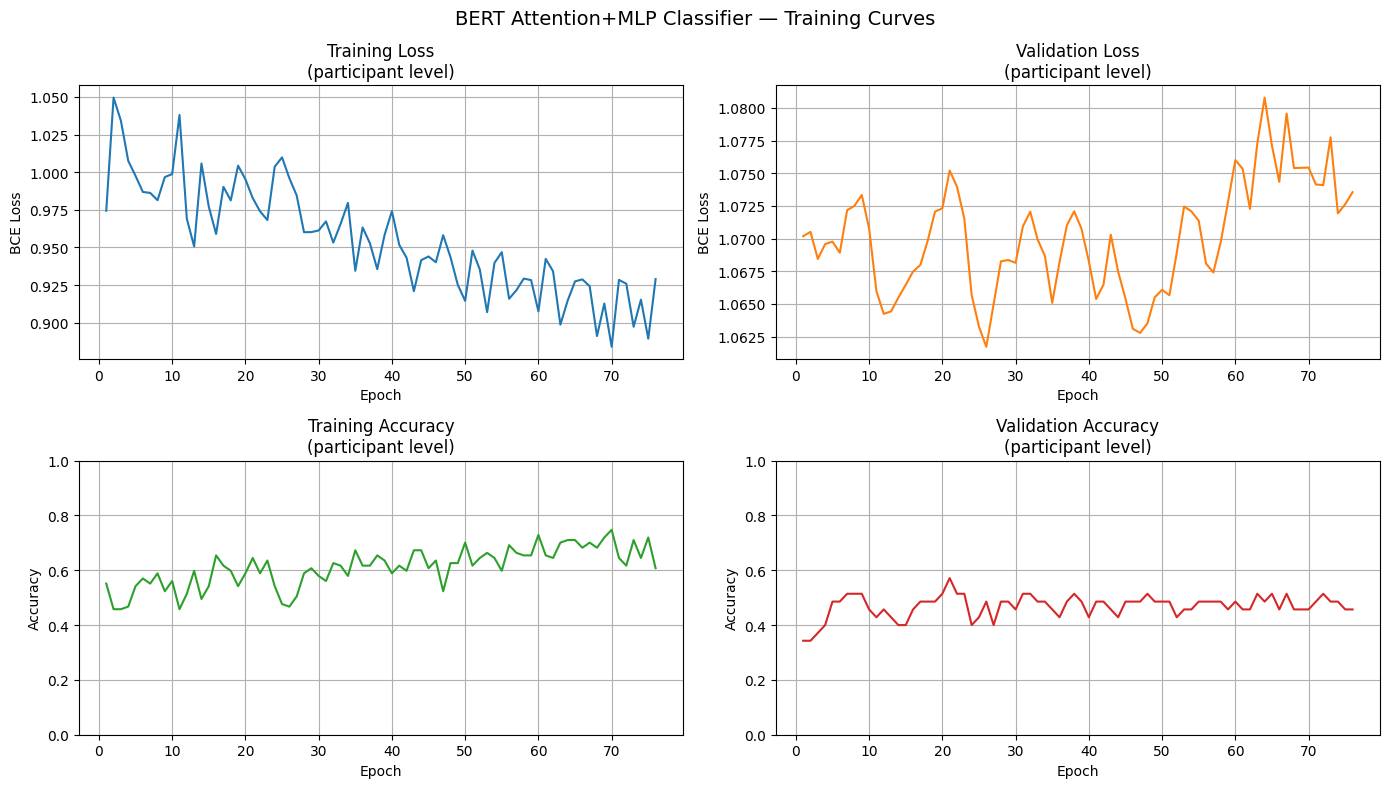

In [44]:
epochs_ran = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(epochs_ran, history["train_loss"], color="tab:blue")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("BCE Loss")
axes[0, 0].set_title("Training Loss\n(participant level)")
axes[0, 0].grid(True)

axes[0, 1].plot(epochs_ran, history["val_loss"], color="tab:orange")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("BCE Loss")
axes[0, 1].set_title("Validation Loss\n(participant level)")
axes[0, 1].grid(True)

axes[1, 0].plot(epochs_ran, history["train_acc"], color="tab:green")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Accuracy")
axes[1, 0].set_title("Training Accuracy\n(participant level)")
axes[1, 0].set_ylim(0, 1)
axes[1, 0].grid(True)

axes[1, 1].plot(epochs_ran, history["val_acc"], color="tab:red")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Accuracy")
axes[1, 1].set_title("Validation Accuracy\n(participant level)")
axes[1, 1].set_ylim(0, 1)
axes[1, 1].grid(True)

plt.suptitle("BERT Attention+MLP Classifier — Training Curves", fontsize=14)
plt.tight_layout()
plt.show()

## 10. Attention Weight Visualisation

Inspect which transcript chunks the model attends to for a sample of test participants.
High attention weights indicate the model found those chunks most informative for its prediction.

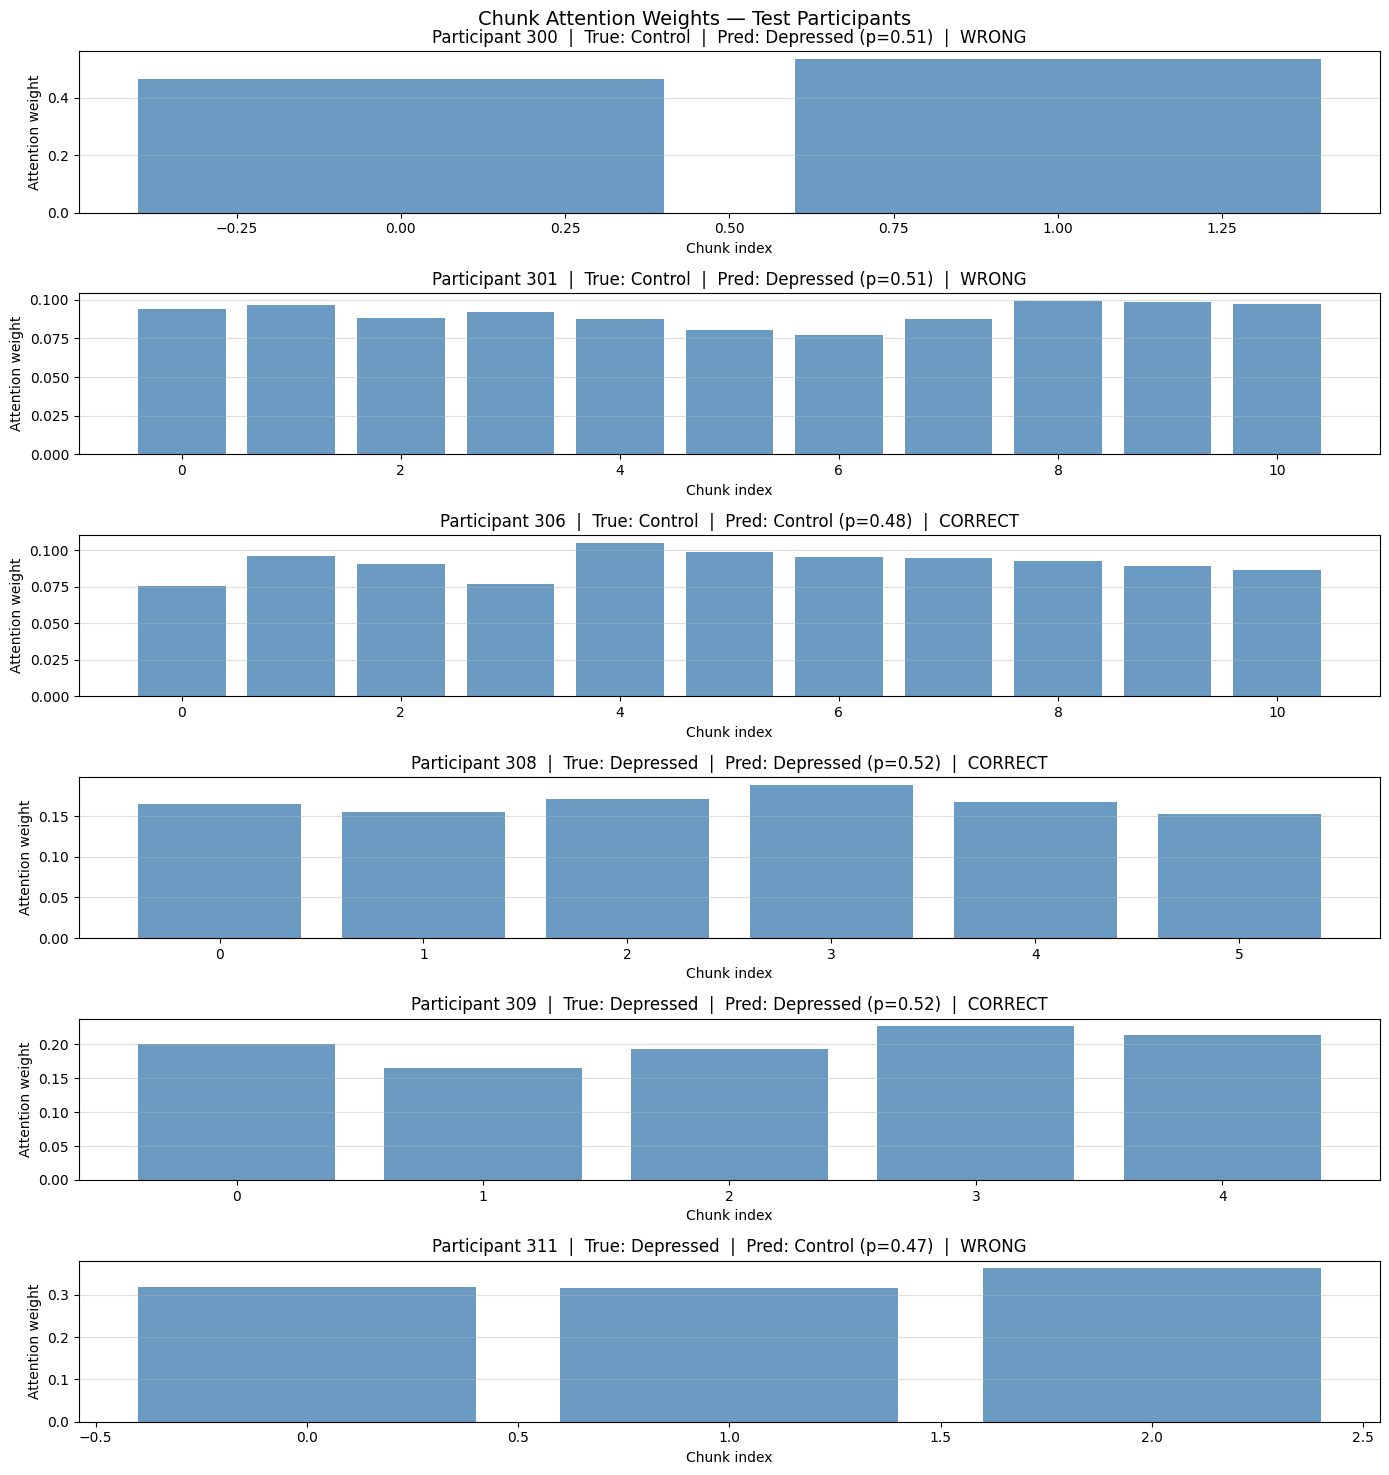

In [45]:
model.eval()
n_show = min(6, len(splits_list["test"]))
fig, axes = plt.subplots(n_show, 1, figsize=(14, 2.5 * n_show))
if n_show == 1:
    axes = [axes]

with torch.no_grad():
    for ax, (pid, data) in zip(axes, splits_list["test"][:n_show]):
        feats = torch.tensor(
            np.array(data["feats"]), dtype=torch.float32, device=DEVICE
        )
        attn_weights = torch.softmax(
            model.attention(feats), dim=0
        ).squeeze().cpu().numpy()   # (T,)

        logit     = model(feats)
        pred_prob = torch.sigmoid(logit).item()
        pred      = 1 if pred_prob >= best_thresh else 0
        true_lbl  = data["label"]

        chunk_axis = np.arange(len(attn_weights))
        ax.bar(chunk_axis, attn_weights, color="steelblue", alpha=0.8)
        ax.set_xlabel("Chunk index")
        ax.set_ylabel("Attention weight")
        status    = "CORRECT" if pred == true_lbl else "WRONG"
        label_str = "Depressed" if true_lbl == 1 else "Control"
        pred_str  = "Depressed" if pred == 1 else "Control"
        ax.set_title(
            f"Participant {pid}  |  True: {label_str}  |  "
            f"Pred: {pred_str} (p={pred_prob:.2f})  |  {status}"
        )
        ax.grid(True, axis="y", alpha=0.4)

plt.suptitle("Chunk Attention Weights — Test Participants", fontsize=14)
plt.tight_layout()
plt.show()

## 11. Evaluation on Test Set

Loads the best checkpoint (lowest validation loss) and reports participant-level
**accuracy, precision, recall, and F1 score** using the validation-tuned threshold.

In [46]:
# best_ckpt and model already loaded + threshold tuned at end of training cell
_, _, test_results_df = evaluate("test", threshold=best_thresh)

y_true = test_results_df["label"].values.astype(int)
y_pred = test_results_df["pred"].values.astype(int)

test_acc  = accuracy_score(y_true, y_pred)
test_prec = precision_score(y_true, y_pred, zero_division=0)
test_rec  = recall_score(y_true, y_pred, zero_division=0)
test_f1   = f1_score(y_true, y_pred, zero_division=0)

print(f"Best checkpoint : epoch {best_ckpt['epoch']}  "
      f"(val loss {best_ckpt['val_loss']:.4f}, val acc {best_ckpt['val_acc']:.4f})")
print(f"Decision threshold: {best_thresh:.2f}  (tuned on validation macro-F1)")
print(f"\nParticipants evaluated: {len(test_results_df)}")
print()
print("── Test-set results (participant level) ──────────────────")
print(f"  Accuracy  : {test_acc:.4f}  "
      f"({int(test_acc * len(y_true))}/{len(y_true)} correct)")
print(f"  Precision : {test_prec:.4f}")
print(f"  Recall    : {test_rec:.4f}")
print(f"  F1 Score  : {test_f1:.4f}")
print()
print(classification_report(y_true, y_pred, target_names=["Control", "Depressed"], zero_division=0))

Best checkpoint : epoch 26  (val loss 1.0617, val acc 0.4857)
Decision threshold: 0.50  (tuned on validation macro-F1)

Participants evaluated: 47

── Test-set results (participant level) ──────────────────
  Accuracy  : 0.5319  (25/47 correct)
  Precision : 0.3750
  Recall    : 0.8571
  F1 Score  : 0.5217

              precision    recall  f1-score   support

     Control       0.87      0.39      0.54        33
   Depressed       0.38      0.86      0.52        14

    accuracy                           0.53        47
   macro avg       0.62      0.63      0.53        47
weighted avg       0.72      0.53      0.54        47



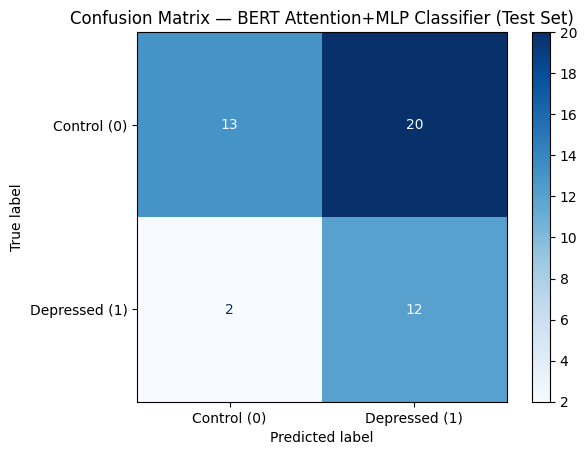

In [47]:
cm   = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Control (0)", "Depressed (1)"]
)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — BERT Attention+MLP Classifier (Test Set)")
plt.show()